In [1]:
!pip install pymysql

     --------------------------------------- 45.3/45.3 kB 64.1 kB/s eta 0:00:00


In [2]:
#1. 导入库并连接 MySQL
import pandas as pd
import pymysql
from datetime import datetime

# 连接 MySQL 数据库
conn = pymysql.connect(
    host='127.0.0.1',
    user='root',
    password='123456',   # 自己的密码
    database='ecommerce',
    charset='utf8mb4'
)

# 查询购买行为数据（需要 datetime 列）
query = """
SELECT user_id, datetime
FROM user_behavior
WHERE behavior_type = 'buy'
  AND datetime IS NOT NULL
"""
df = pd.read_sql(query, conn)
conn.close()

print("数据量:", len(df))
df.head()

D:\ProgramData\Anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


数据量: 4329


,user_id,datetime
0,100,2017-11-25 03:18:00
1,100,2017-11-25 13:45:00
2,100,2017-11-27 05:10:00
3,100,2017-11-27 07:21:00
4,100,2017-11-27 13:39:00


In [3]:
#2. 数据预处理
# 确保 datetime 是时间类型
df['datetime'] = pd.to_datetime(df['datetime'])

# 以数据集中的最大日期作为“今天”（计算 R 用）
current_date = df['datetime'].max()
print("当前计算基准日:", current_date)

当前计算基准日: 2017-12-03 15:54:00


In [4]:
#3. 计算 R 和 F
# R: 最近一次购买距离今天的天数
# F: 购买次数
rfm = df.groupby('user_id').agg({
    'datetime': lambda x: (current_date - x.max()).days
}).rename(columns={'datetime': 'Recency'})

rfm['Frequency'] = df.groupby('user_id').size()

rfm.head()

,Recency,Frequency
user_id,,
100,5,8
10008,1,3
10009,0,10
10020,6,1
10021,2,1


In [7]:
#4. 查看 Recency 和 Frequency 的统计信息
print("Recency 描述统计：")
print(rfm['Recency'].describe())
print("\nRecency 值分布（前10个）：")
print(rfm['Recency'].value_counts().sort_index().head(10))

print("\nFrequency 描述统计：")
print(rfm['Frequency'].describe())
print("\nFrequency 值分布（前10个）：")
print(rfm['Frequency'].value_counts().sort_index().head(10))

Recency 描述统计：
count    1369.000000
mean        2.418554
std         2.300071
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max         8.000000
Name: Recency, dtype: float64

Recency 值分布（前10个）：
0    362
1    268
2    176
3    160
4    122
5    105
6     71
7     68
8     37
Name: Recency, dtype: int64

Frequency 描述统计：
count    1369.000000
mean        3.162162
std         3.508136
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        57.000000
Name: Frequency, dtype: float64

Frequency 值分布（前10个）：
1     459
2     319
3     203
4     125
5      93
6      46
7      33
8      24
9      11
10     13
Name: Frequency, dtype: int64


In [8]:
#5. 自定义 R 分箱边界（Recency 范围 0~8）
# 分数越高表示越近（5=最近，1=最远）
r_bins = [0, 1, 2, 4, 6, 9]   # 区间: [0,1) [1,2) [2,4) [4,6) [6,9]
rfm['R_score'] = pd.cut(rfm['Recency'], bins=r_bins, labels=[5,4,3,2,1], right=False).astype(int)

# 自定义 F 分箱边界（Frequency 范围 1~57，大部分在1~10）
# 分数越高表示购买次数越多（1=最少，5=最多）
f_bins = [0, 1, 2, 4, 6, 100]   # 区间: [0,1) [1,2) [2,4) [4,6) [6,100)
rfm['F_score'] = pd.cut(rfm['Frequency'], bins=f_bins, labels=[1,2,3,4,5], right=False).astype(int)

# 验证分数分布
print("R_score 分布：")
print(rfm['R_score'].value_counts().sort_index())
print("\nF_score 分布：")
print(rfm['F_score'].value_counts().sort_index())

R_score 分布：
1    176
2    227
3    336
4    268
5    362
Name: R_score, dtype: int64

F_score 分布：
2    459
3    522
4    218
5    170
Name: F_score, dtype: int64


In [9]:
#6. 用户分层
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return '高价值用户'
    elif row['R_score'] >= 4 and row['F_score'] < 4:
        return '潜力用户'
    elif row['R_score'] < 4 and row['F_score'] >= 4:
        return '流失风险用户'
    else:
        return '一般用户'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

# 统计各层级用户数
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

一般用户      592
潜力用户      389
高价值用户     241
流失风险用户    147
Name: segment, dtype: int64


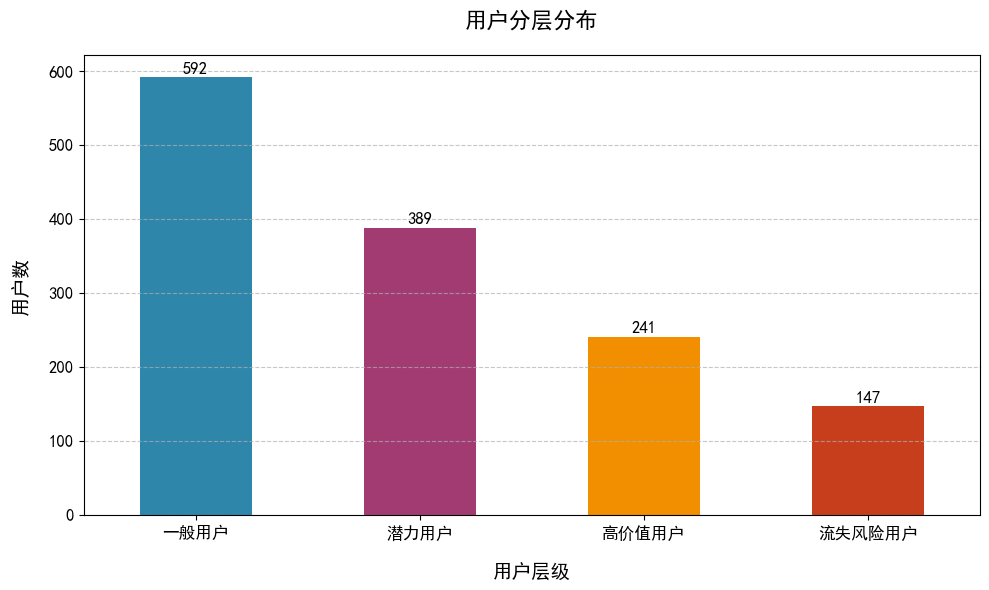

In [11]:
#7. 可视化占比（饼图或柱状图）
import matplotlib.pyplot as plt
# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制柱状图（添加数据标签、优化样式）
ax = segment_counts.plot(
    kind='bar', 
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'],
    figsize=(10, 6)  # 设置图表大小
)

# 添加数据标签（在柱子顶部显示具体人数）
for i, v in enumerate(segment_counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=12)

# 优化图表样式
plt.title('用户分层分布', fontsize=16, pad=20)
plt.xlabel('用户层级', fontsize=14, labelpad=15)
plt.ylabel('用户数', fontsize=14, labelpad=15)
plt.xticks(rotation=0, fontsize=12)  # X轴标签不旋转
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 添加横向网格线
plt.tight_layout()  # 自动调整布局，避免标签被截断
plt.show()

In [12]:
#8. 保存结果到 CSV（供 Power BI 使用）
rfm.to_csv('rfm_result.csv')
print("RFM 结果已保存到 rfm_result.csv")

RFM 结果已保存到 rfm_result.csv
